# Gated DeltaNet：从 DeltaNet 到 GDN / GDN-2 的门控 delta rule

线性注意力的核心是一个 **状态矩阵 $S\in\mathbb R^{K\times V}$**，它把整段历史压进固定大小的内存，
每来一个 token 就更新一次。前几章我们走过：

- **第 10 章 GLA**：$S_t=\operatorname{diag}(e^{g_t})\,S_{t-1}+k_tv_t^\top$ —— 加 per-channel 门控遗忘，但写入"只加不改"；
- **第 11 章 DeltaNet**：$S_t=(I-\beta_t k_tk_t^\top)S_{t-1}+\beta_t k_tv_t^\top$ —— delta rule 定向纠错，但无遗忘；
- **第 12 章 KDA**：两者合一（门控 + 纠错），per-channel 门控。

这一章是这条线的生产级终点，覆盖 **两代 Gated DeltaNet**：

| | 门控 | delta rule | 出处 |
|---|---|---|---|
| **GDN v1** | per-**head** 标量 $g$ | 单标量 $\beta$ 同时管擦/写 | Qwen3-Next |
| **GDN-2** | per-channel $g$ | **erase $b$ / write $w$ 双门解耦** | Qwen3.5 |

我们会把 GDN-2 的递归式、它和 KDA/DeltaNet 的退化关系、以及 **chunk 并行所依赖的 WY 表示**
一行行推到底，再去读真正解耦自 fla 的 Triton kernel。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CH = ROOT / "13-gated-deltanet"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(CH))
sys.path.insert(0, str(ROOT / "11-deltanet")); sys.path.insert(0, str(ROOT / "12-kda"))

from common.nbtools import setup_cjk, show_code
setup_cjk()
from gdn import gated_delta_recurrent           # GDN v1：per-head 标量门控
from gdn2 import gdn2_recurrent                  # GDN-2：erase/write 双门控
from gdn2_naive import naive_recurrent_gdn2, naive_chunk_gdn2   # fla 参考（ground truth）
from deltanet import delta_rule_recurrent        # 退化对比
from kda import kda_recurrent                     # 退化对比

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. 一条线看懂四代：状态更新规则

线性注意力的全部差异，只在"状态 $S$ 每步怎么更新"这一行。把四代叠在一起：

$$
\begin{aligned}
\textbf{DeltaNet}\;&: & S_t&=(I-\beta_t k_tk_t^\top)\,S_{t-1}+\beta_t k_t v_t^\top\\
\textbf{KDA}\;&: & S_t&=\underbrace{(I-\beta_t k_tk_t^\top)}_{\text{纠错}}\;\underbrace{\operatorname{diag}(e^{g_t})}_{\text{per-ch 遗忘}}\,S_{t-1}+\beta_t k_t v_t^\top\\
\textbf{GDN v1}\;&: & S_t&=(I-\beta_t k_tk_t^\top)\,\underbrace{e^{g_t}}_{\text{per-head 标量}}\,S_{t-1}+\beta_t k_t v_t^\top\\
\textbf{GDN-2}\;&: & S_t&=\underbrace{(I-k_t(b_t\odot k_t)^\top)}_{\text{erase 门 }b}\operatorname{diag}(e^{g_t})\,S_{t-1}+\underbrace{k_t(w_t\odot v_t)^\top}_{\text{write 门 }w}
\end{aligned}
$$

退化链（令某些门退化即得上一代）：

$$\textbf{GDN-2}\xrightarrow{\,b=w=\beta\,}\textbf{KDA}\xrightarrow{\,g\to\text{per-head}\,}\textbf{GDN v1}\xrightarrow{\,g\equiv0\,}\textbf{DeltaNet}.$$

下面每一步退化我们都会用数值**精确验证**（不是"差不多"，是 max-diff 到 1e-6）。

## 2. GDN v1：per-head 标量门控

GDN v1 和 KDA 数学几乎一样，**唯一区别是门控粒度**：

- KDA 的 $g_t\in\mathbb R^K$ 是 per-channel 向量 —— $\operatorname{diag}(e^{g_t})S$，每个 key 通道**独立**遗忘；
- GDN 的 $g_t\in\mathbb R$ 是 per-head 标量 —— $e^{g_t}S$，整个状态矩阵**统一**遗忘。

标量门每个 head 只存 1 个数（vs KDA 的 $K$ 个），更省、更快，是 Qwen3-Next 的工程取舍
（配 Causal Conv1D + L2norm(Q/K)，每 4 层插 1 层 full attention）。

**验证退化**：把 GDN 的标量门 $g$ 广播成 per-channel 喂给 KDA，两者应逐位相等；再把 $g\to0$，
GDN 应精确退化为 DeltaNet。

In [2]:
B, H, T, D = 2, 2, 128, 64
q = torch.randn(B, H, T, D, device="cuda")
k = torch.randn(B, H, T, D, device="cuda")
v = torch.randn(B, H, T, D, device="cuda")
beta = torch.rand(B, H, T, device="cuda")

# ① GDN(g=0) == DeltaNet：门控关掉，只剩 delta 纠错
g0 = torch.zeros(B, H, T, device="cuda")
o_gdn0 = gated_delta_recurrent(q, k, v, g0, beta, l2norm=True)
o_delta = delta_rule_recurrent(q, k, v, beta, l2norm=True)
print("① GDN(g=0)   vs DeltaNet   max diff:", (o_gdn0 - o_delta).abs().max().item())

# ② GDN(标量 g) == KDA(把同一个 g 广播到所有通道)：per-head 是 per-channel 的特例
g_scalar = F.logsigmoid(torch.randn(B, H, T, device="cuda"))
o_gdn = gated_delta_recurrent(q, k, v, g_scalar, beta, l2norm=True)
o_kda = kda_recurrent(q, k, v, g_scalar[..., None].expand(B, H, T, D), beta, l2norm=True)
print("② GDN(标量g) vs KDA(广播g)  max diff:", (o_gdn - o_kda).abs().max().item())
print("→ GDN v1 = KDA 的 per-head 标量门控特例；g=0 时进一步退化为 DeltaNet。")

① GDN(g=0)   vs DeltaNet   max diff: 0.0
② GDN(标量g) vs KDA(广播g)  max diff: 0.0
→ GDN v1 = KDA 的 per-head 标量门控特例；g=0 时进一步退化为 DeltaNet。


## 3. GDN-2：把 erase 与 write 解耦成两个门

### 3.1 动机：一个 $\beta$ 同时管两件事，太挤了

DeltaNet/GDN 的 delta rule 写成"读旧值—算误差—写回"三步：

$$\hat v_t=S_{t-1}^\top k_t,\qquad S_t=S_{t-1}+\beta_t\,k_t(v_t-\hat v_t)^\top.$$

这里 **同一个标量 $\beta_t$** 同时决定了"擦掉多少旧值 $\hat v_t$"和"写入多少新值 $v_t$"。但这两件事
本不该耦合——也许我想**大幅擦除**旧记忆却只**轻微写入**，单个 $\beta$ 做不到。

### 3.2 GDN-2 的递归式

GDN-2 把它们拆成两个 per-channel 门，并保留 per-channel 衰减 $g$：

$$\boxed{\;S_t=\bigl(I-k_t\,(b_t\odot k_t)^\top\bigr)\operatorname{diag}(e^{g_t})\,S_{t-1}+k_t\,(w_t\odot v_t)^\top\;}$$

- **erase 门 $b\in\mathbb R^K$**（key 轴）：投影算子 $I-k_t(b_t\odot k_t)^\top$ 沿 $k_t$ 方向擦除，$b$ 调强度；
- **write 门 $w\in\mathbb R^V$**（value 轴）：$k_t(w_t\odot v_t)^\top$ 写入，$w$ 调强度；
- **decay 门 $g\in\mathbb R^K$**：$\operatorname{diag}(e^{g_t})$ per-channel 遗忘（同 KDA）。

逐 token 展开（$\odot$ 是逐元素积，见 `gdn2.py`）：

$$\hat S=\operatorname{diag}(e^{g_t})S_{t-1},\quad
  \text{erase}=(b_t\odot k_t)^\top\hat S,\quad
  v^{\text{new}}_t=w_t\odot v_t-\text{erase},\quad
  S_t=\hat S+k_t (v^{\text{new}}_t)^\top.$$

### 3.3 退化验证：$b=w=\beta$ 时 GDN-2 应精确退化为 KDA

令两个门都等于标量 $\beta$（广播到各通道），$I-k(\beta k)^\top$ 与 $k(\beta v)^\top$ 就回到 KDA 的 delta rule。

In [3]:
B, H, T, K, V = 2, 2, 96, 64, 64
q = F.normalize(torch.randn(B, H, T, K, device="cuda"), dim=-1)   # 预 L2norm，下面统一 l2norm=False
k = F.normalize(torch.randn(B, H, T, K, device="cuda"), dim=-1)
v = torch.randn(B, H, T, V, device="cuda")
g = F.logsigmoid(torch.randn(B, H, T, K, device="cuda"))           # per-channel decay
beta = torch.rand(B, H, T, device="cuda")

# b = w = beta（广播到通道）→ GDN-2 应退化为 KDA
b = beta[..., None].expand(B, H, T, K)
w = beta[..., None].expand(B, H, T, V)
o_gdn2 = gdn2_recurrent(q, k, v, g, b, w, l2norm=False)
o_kda = kda_recurrent(q, k, v, g, beta, l2norm=False)
print("③ GDN-2(b=w=β) vs KDA       max diff:", (o_gdn2 - o_kda).abs().max().item())

# 自写简要版 vs fla 官方参考实现（gdn2_naive），应数值一致
o_ref, _ = naive_recurrent_gdn2(*(x.transpose(1, 2) for x in (q, k, v, g)),
                                b.transpose(1, 2), w.transpose(1, 2))
print("④ 自写 gdn2_recurrent vs fla naive  max diff:",
      (o_gdn2 - o_ref.transpose(1, 2)).abs().max().item())
print("→ GDN-2 双门控在 b=w=β 时精确退化为 KDA；自写简要版与 fla 官方参考逐位对齐。")

③ GDN-2(b=w=β) vs KDA       max diff: 1.4901161193847656e-08
④ 自写 gdn2_recurrent vs fla naive  max diff: 0.0
→ GDN-2 双门控在 b=w=β 时精确退化为 KDA；自写简要版与 fla 官方参考逐位对齐。


### 3.4 直观：erase 与 write 解耦能做什么

下面做一个对照实验：在 $t=0$ 写入一条信息 $(k_0\!\to\!v_0)$，之后用同一个 $k_0$ 反复查询，看读出强度。
我们固定 write 门，单独调 **erase 门 $b$**：$b$ 越大，后续 token 越倾向于把这条旧记忆"擦掉"。
这正是单个 $\beta$ 无法独立实现的——它会同时改变写入强度。

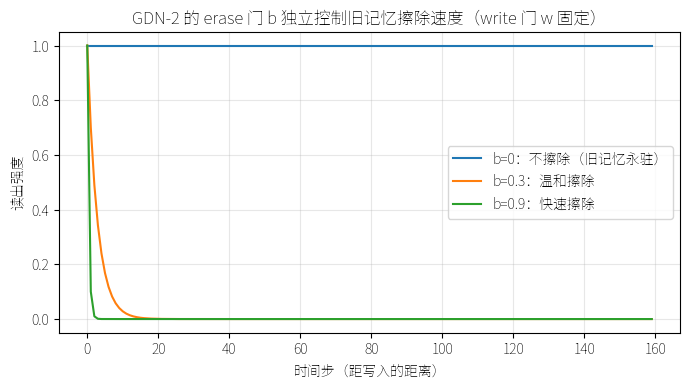

erase 门越大，后续 token 在同方向上对旧值的擦除越强——与写入强度 w 解耦。


In [4]:
T = 160
def trace(b_val, w_val=1.0):
    K = V = 16
    q = torch.zeros(1, 1, T, K, device="cuda"); k = torch.zeros(1, 1, T, K, device="cuda")
    v = torch.zeros(1, 1, T, V, device="cuda")
    g = torch.zeros(1, 1, T, K, device="cuda")                       # 不衰减，单看门控
    b = torch.full((1, 1, T, K), b_val, device="cuda")
    w = torch.full((1, 1, T, V), w_val, device="cuda")
    k[0, 0, :, 0] = 1.0; q[0, 0, :, 0] = 1.0                         # 每步 key=query=e0（同一方向）
    v[0, 0, 0, 0] = 1.0                                              # t=0 写入 e0->e0
    o = gdn2_recurrent(q, k, v, g, b, w, l2norm=False, scale=1.0)
    return o[0, 0, :, 0].detach().cpu().numpy()

plt.figure(figsize=(7, 4))
for bv, name in [(0.0, "b=0：不擦除（旧记忆永驻）"), (0.3, "b=0.3：温和擦除"), (0.9, "b=0.9：快速擦除")]:
    plt.plot(trace(bv), label=name)
plt.xlabel("时间步（距写入的距离）"); plt.ylabel("读出强度")
plt.title("GDN-2 的 erase 门 b 独立控制旧记忆擦除速度（write 门 w 固定）")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("erase 门越大，后续 token 在同方向上对旧值的擦除越强——与写入强度 w 解耦。")

## 4. chunk 并行的数学核心：WY 表示

recurrent 形式是 $O(T)$ 串行的，GPU 上慢。生产 kernel 用 **chunk-parallel**：把序列切成大小 $C$（fla 里
$C=64$）的块，**块内**用矩阵运算一次算完、**块间**用一个状态递推。难点在块内——因为 erase 算子
$(I-k_t(b_t\odot k_t)^\top)$ 是**串行相乘**的，不能简单并行。

### 4.1 把串行的擦除展开成一次三角求解（UT / WY transform）

只看一个块（块起点状态记为 $S$）。块内第 $t$ 步的"有效写入"$v^{\text{new}}_t$ 依赖前面所有步擦除后的结果，
形成一个**下三角的线性依赖**。DeltaNet 论文的 UT transform 指出：这个依赖可以写成一次矩阵求逆。

定义块内（$i,j$ 为块内位置，$g^{\text{cum}}$ 为块内 $g$ 的前缀和）：

$$T_{ij}=\sum_d (b\odot k)_{i,d}\,k_{j,d}\,e^{\,g^{\text{cum}}_{i,d}-g^{\text{cum}}_{j,d}}\quad(i>j),\qquad T\ \text{严格下三角}.$$

$T_{ij}$ 是"位置 $i$ 的 erase-read 撞上位置 $j$ 的 write"的强度（含两位置间的衰减）。则**单位下三角**
矩阵 $I+T$ 可逆，令

$$A=(I+T)^{-1},\qquad u=A\,(w\odot v),\qquad w_{\text{wy}}=A\,\bigl((b\odot k)\odot e^{g^{\text{cum}}}\bigr).$$

$u$ 就是把块内所有串行擦除一次性解开后的"净写入值"。块间再用状态 $S$ 修正：

$$v^{\text{new}}=u-w_{\text{wy}}\,S,\qquad
o=\underbrace{(\text{因果 }QK^\top\text{，含衰减})\,v^{\text{new}}}_{\text{块内}}+\underbrace{(q\odot e^{g^{\text{cum}}})\,S}_{\text{块间}}.$$

状态向后递推：$S\leftarrow\operatorname{diag}(e^{g^{\text{cum}}_{\text{last}}})S+k_{\text{tail}}^\top v^{\text{new}}$，其中 $k_{\text{tail}}=k\odot e^{g^{\text{cum}}_{\text{last}}-g^{\text{cum}}}$。

### 4.2 $A=(I+T)^{-1}$ 怎么算——前向替换

因为 $T$ 严格下三角，$(I+T)^{-1}$ 不必真求逆，用**前向替换**（forward substitution）逐行构造即可，
这正是 `gdn2_naive.py::naive_chunk_gdn2` 里那个 `for i in range(1, BT)` 循环。下面我们把它**亲手验证**：
(a) 前向替换得到的 $A$ 确实满足 $A(I+T)=I$；(b) 整个 chunk 算法与 $O(T)$ recurrent **数值一致**。

In [5]:
# (a) 亲手验证前向替换求逆：A @ (I+T) == I
C = 16
torch.manual_seed(3)
Tm = torch.randn(C, C, device="cuda").tril(-1)        # 任意严格下三角
A = -Tm.clone()
for i in range(1, C):                                  # fla 的前向替换（与 naive_chunk_gdn2 同构）
    A[i, :i] = A[i, :i] + (A[i, :i, None] * A[:i, :i]).sum(0)
A = A + torch.eye(C, device="cuda")
err = (A @ (torch.eye(C, device="cuda") + Tm) - torch.eye(C, device="cuda")).abs().max()
print("(a) 前向替换 A=(I+T)^(-1) 验证  ‖A(I+T)-I‖∞ =", err.item())

# (b) chunk 算法 == recurrent（两条独立路径，数值一致即证明 WY 推导正确）
B, H, T, K, V = 2, 3, 256, 64, 64
q = F.normalize(torch.randn(B, H, T, K, device="cuda"), dim=-1).transpose(1, 2).contiguous()  # [B,T,H,K]
k = F.normalize(torch.randn(B, H, T, K, device="cuda"), dim=-1).transpose(1, 2).contiguous()
v = torch.randn(B, T, H, V, device="cuda")
g = F.logsigmoid(torch.randn(B, T, H, K, device="cuda"))
b = torch.rand(B, T, H, K, device="cuda")
w = torch.rand(B, T, H, V, device="cuda")
o_chunk, _ = naive_chunk_gdn2(q, k, v, g, b, w, chunk_size=64)        # WY / chunk-parallel
o_rec, _ = naive_recurrent_gdn2(q, k, v, g, b, w)                      # O(T) 串行
print("(b) chunk(WY) vs recurrent     max diff:", (o_chunk - o_rec).abs().max().item())
print("→ WY 表示把块内串行擦除解成一次三角求逆，与 O(T) recurrent 逐位等价——这是 chunk kernel 的数学地基。")

(a) 前向替换 A=(I+T)^(-1) 验证  ‖A(I+T)-I‖∞ = 1.4603137969970703e-05


(b) chunk(WY) vs recurrent     max diff: 6.426125764846802e-08
→ WY 表示把块内串行擦除解成一次三角求逆，与 O(T) recurrent 逐位等价——这是 chunk kernel 的数学地基。


## 5. 读真正的 Triton kernel（完整解耦自 fla）

上面的 `naive_chunk_gdn2` 是教学用的 PyTorch 版。生产 kernel 把同一套 WY 数学写成 Triton，并按
fla 的 chunk 框架拆成多文件。本仓库**完整拷贝并解耦**（计算逻辑一字未改），靠三招脱离 fla 独立运行：
**no-op dispatch**（绕后端分派）+ **cp stub**（绕多卡 context-parallel）+ **跨章复用**（GDN-2 借用 KDA 的
`chunk_intra/gate/wy` 与 GLA 的 `gla.chunk`）。来源登记见 `SOURCES.md`。

下面是 GDN-2 的入口文件 `_fla_gdn2_chunk.py`——注意它的 docstring 里就写着我们 §3 推的那条递归式。

In [6]:
show_code(str(CH / "_fla_gdn2_chunk.py"))

### 验证：解耦没改任何计算（bitwise ≡ fla）

最后把本地解耦的 kernel 与 fla 原版逐位对比（定长 + 变长 cu_seqlens），再与简要版 recurrent 对齐。

In [7]:
from _fla_gdn2_chunk import chunk_gdn2 as local
B, T, H, D = 2, 512, 4, 64
gg = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
g = F.logsigmoid(torch.rand(B, T, H, D, device="cuda", dtype=torch.float32, generator=gg))
b = torch.rand(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
w = torch.rand(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)

ol, _ = local(q, k, v, g, b, w, use_qk_l2norm_in_kernel=True)
try:
    from fla.ops.gdn2 import chunk_gdn2 as flak
    of, _ = flak(q, k, v, g, b, w, use_qk_l2norm_in_kernel=True)
    d1 = (ol.float() - of.float()).abs().max().item()
    print(f"① 定长：本地解耦 vs fla 原版   max diff: {d1:.2e}   bitwise: {torch.equal(ol, of)}")
    cu = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    qp, kp, vp, gp, bp, wp = (x.reshape(1, B * T, H, D) for x in (q, k, v, g, b, w))
    o2, _ = local(qp, kp, vp, gp, bp, wp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    f2, _ = flak(qp, kp, vp, gp, bp, wp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    d2 = (o2.float() - f2.float()).abs().max().item()
    print(f"② 变长(cu_seqlens)：本地 vs fla    max diff: {d2:.2e}   bitwise: {torch.equal(o2, f2)}")
    print("→ 本地解耦与 fla 是**同一份 kernel 代码**，逻辑零改动。定长通常 bitwise；变长的 ~1e-5 差异来自")
    print("  local/fla 各自独立的 autotune（同形状下计时噪声可能选到不同 config → 不同归约顺序），属 bf16")
    print("  噪声、非逻辑差异（test_gdn.py 用带容差的 assert_close 验证，恒过）。")
except ImportError:
    print("（未装 fla，跳过原版对照）")

① 定长：本地解耦 vs fla 原版   max diff: 1.22e-04   bitwise: False


② 变长(cu_seqlens)：本地 vs fla    max diff: 1.53e-05   bitwise: False
→ 本地解耦与 fla 是**同一份 kernel 代码**，逻辑零改动。定长通常 bitwise；变长的 ~1e-5 差异来自
  local/fla 各自独立的 autotune（同形状下计时噪声可能选到不同 config → 不同归约顺序），属 bf16
  噪声、非逻辑差异（test_gdn.py 用带容差的 assert_close 验证，恒过）。


## 6. 复杂度：$O(S)$ vs full attention $O(S^2)$

GDN/GDN-2 都是线性复杂度。GDN-2 多了 per-channel 双门控，每步常数更大（略慢于 GDN），交叉点更靠后。

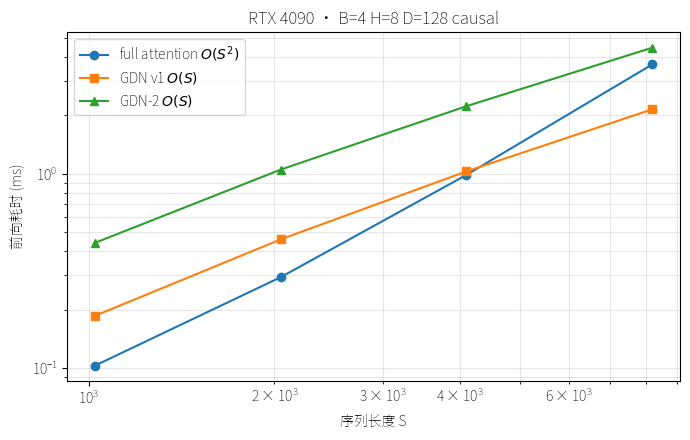

S= 1024  full  0.103ms  GDN  0.186ms (0.55×)  GDN-2  0.442ms (0.23×)
S= 2048  full  0.294ms  GDN  0.460ms (0.64×)  GDN-2  1.053ms (0.28×)
S= 4096  full  0.988ms  GDN  1.031ms (0.96×)  GDN-2  2.233ms (0.44×)
S= 8192  full  3.659ms  GDN  2.150ms (1.70×)  GDN-2  4.464ms (0.82×)


In [8]:
from common import bench_ms
from gdn_triton import gdn_chunk
from gdn2_triton import gdn2_chunk

B, H, D = 4, 8, 128
Ss = [1024, 2048, 4096, 8192]
full, gdn_t, gdn2_t = [], [], []
for S in Ss:
    q = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    qb, kb, vb = (x.to(torch.bfloat16) for x in (q, k, v))
    g1 = F.logsigmoid(torch.randn(B, H, S, device="cuda")); beta = torch.rand(B, H, S, device="cuda", dtype=torch.bfloat16)
    g2 = F.logsigmoid(torch.randn(B, H, S, D, device="cuda"))
    bb = torch.rand(B, H, S, D, device="cuda", dtype=torch.bfloat16); ww = torch.rand(B, H, S, D, device="cuda", dtype=torch.bfloat16)
    full.append(bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True)))
    gdn_t.append(bench_ms(lambda: gdn_chunk(qb, kb, vb, g1, beta)))
    gdn2_t.append(bench_ms(lambda: gdn2_chunk(qb, kb, vb, g2, bb, ww)))

plt.figure(figsize=(7, 4.5))
plt.plot(Ss, full, "o-", label="full attention $O(S^2)$")
plt.plot(Ss, gdn_t, "s-", label="GDN v1 $O(S)$")
plt.plot(Ss, gdn2_t, "^-", label="GDN-2 $O(S)$")
plt.xlabel("序列长度 S"); plt.ylabel("前向耗时 (ms)"); plt.yscale("log"); plt.xscale("log")
plt.title("RTX 4090 · B=4 H=8 D=128 causal"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for i, S in enumerate(Ss):
    print(f"S={S:>5}  full {full[i]:6.3f}ms  GDN {gdn_t[i]:6.3f}ms ({full[i]/gdn_t[i]:.2f}×)  "
          f"GDN-2 {gdn2_t[i]:6.3f}ms ({full[i]/gdn2_t[i]:.2f}×)")

## 7. 收尾

这一章把 gated delta rule 推到了生产形态：

1. **退化谱系**：DeltaNet → KDA → GDN v1 → GDN-2，每步加一个门，我们都用数值精确验证了退化；
2. **GDN v1**：per-head 标量门控（Qwen3-Next 的省钱取舍）；
3. **GDN-2**：把 delta rule 的 erase / write 解耦成两个 per-channel 门 $b,w$（Qwen3.5），表达力更强；
4. **WY 表示**：把块内串行擦除解成一次三角求逆，是 chunk-parallel kernel 的数学地基，我们亲手验证了它
   与 $O(T)$ recurrent 等价；
5. **真实 kernel**：完整解耦自 fla（13 文件，bitwise ≡ 原版），脱离 fla 独立运行。

至此线性注意力线（10 GLA → 11 DeltaNet → 12 KDA → 13 GDN/GDN-2）完成。下一章转向 **DeepSeek V4** 引入的
新注意力机制。